# Fractional Polynomial Cox Model — Power Selection via **Self-adaptive Differential Evolution (SaDE)**

This notebook replaces the traditional `scipy.optimize.differential_evolution` optimizer with the **Self-adaptive Differential Evolution ($\$DE$)** algorithm from:

> *Differential Evolution for Integer Programming Problems*, CEC 2007.

### Key upgrade over traditional DE
| | Traditional DE (scipy) | **SaDE** |
|---|---|---|
| Mutation strategy | Fixed (single strategy) | **4 strategies compete adaptively** |
| Control parameters F, CR | Fixed or simple range | **Self-adapted per strategy** |
| Integer handling | Float + floor hack | **Native integer search space** |
| Power index input | Continuous floats floored to int | **Direct integers — no encoding needed** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import warnings

# == SaDE internals ============================================================
from collections import deque
from dataclasses import dataclass, field
from typing import Callable, List, Optional, Tuple

warnings.filterwarnings("ignore")

## 1. Self-adaptive Differential Evolution (SaDE) — Integer Version

Full implementation of the $\$DE$ algorithm. The four competing mutation strategies are:
- **DE/rand/1** — classic random mutation
- **DE/rand-to-best/2** — bias toward current best
- **DE/current-to-rand/1** — perturbation from current individual
- **DE/rand/2** — two-difference mutation for diversity

Strategy selection probabilities and per-strategy CR means update automatically every `lp` generations based on success/failure history.

In [2]:
# =============================================================================
#  SaDE — Self-adaptive Differential Evolution for Integer Programming
# =============================================================================

@dataclass
class SaDEResult:
    x:       np.ndarray        # Best integer solution found
    fun:     float             # Best objective value
    nfev:    int               # Total function evaluations
    ngen:    int               # Generations completed
    history: List[float] = field(default_factory=list)  # best-per-generation


# == Mutation strategies =======================================================

def _choose(n_pop, k, exclude, rng):
    candidates = np.delete(np.arange(n_pop), exclude)
    return rng.choice(candidates, size=k, replace=False)

def _s1_rand_1(pop, F, t, best, rng):
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3])

def _s2_rand_to_best_2(pop, F, t, best, rng):
    r1, r2, r3, r4 = _choose(len(pop), 4, t, rng)
    return (pop[t] + F*(pop[best]-pop[t])
                   + F*(pop[r1]  -pop[r2])
                   + F*(pop[r3]  -pop[r4]))

def _s3_current_to_rand_1(pop, F, t, best, rng):
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F*(pop[r1]-pop[t]) + F*(pop[r2]-pop[r3])

def _s4_rand_2(pop, F, t, best, rng):
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F*(pop[r2]-pop[r3]) + F*(pop[r4]-pop[r5])

STRATEGIES = [_s1_rand_1, _s2_rand_to_best_2, _s3_current_to_rand_1, _s4_rand_2]
N_STRAT = len(STRATEGIES)


# == Integer boundary repair (reflection) =====================================

def _repair(v, lb, ub):
    """Round to integer then reflect out-of-bounds values back into [lb, ub]."""
    v = np.round(v).astype(int)
    lo = v < lb;  v[lo] = lb[lo] + (lb[lo] - v[lo])
    hi = v > ub;  v[hi] = ub[hi] - (v[hi] - ub[hi])
    return np.clip(v, lb, ub)


# == Binomial crossover ========================================================

def _crossover(x, v, CR, rng):
    dim  = len(x)
    mask = rng.random(dim) < CR
    mask[rng.integers(dim)] = True
    return np.where(mask, v, x)


# == Main SaDE class ===========================================================

class SaDE:
    """
    Self-adaptive Differential Evolution for **integer** search spaces.

    Parameters
    ----------
    func       : objective f(x: np.ndarray[int]) -> float  (minimisation)
    bounds     : list of (lb, ub) integer pairs per dimension
    pop_size   : population size  (default 50)
    max_evals  : evaluation budget (default 50 000)
    lp         : learning period for strategy-probability update (default 50)
    seed       : random seed
    callback   : optional callable(best_x, best_f, gen) called each generation
    """

    def __init__(self, func, bounds, pop_size=50, max_evals=50_000,
                 lp=50, seed=None, callback=None):
        self.func      = func
        self.bounds    = bounds
        self.dim       = len(bounds)
        self.lb        = np.array([b[0] for b in bounds], dtype=int)
        self.ub        = np.array([b[1] for b in bounds], dtype=int)
        self.pop_size  = pop_size
        self.max_evals = max_evals
        self.lp        = lp
        self.callback  = callback
        self.rng       = np.random.default_rng(seed)

        # Self-adaptive state
        self.p_strat   = np.ones(N_STRAT) / N_STRAT   # strategy probabilities
        self.cr_means  = np.full(N_STRAT, 0.5)         # per-strategy CR means
        self.ns        = [deque() for _ in range(N_STRAT)]  # successes
        self.nf        = [deque() for _ in range(N_STRAT)]  # failures
        self.cr_ok     = [deque() for _ in range(N_STRAT)]  # successful CRs

    def run(self):
        """Run SaDE and return a SaDEResult."""
        # Initialise population (integer)
        pop = np.column_stack([
            self.rng.integers(self.lb[d], self.ub[d]+1, self.pop_size)
            for d in range(self.dim)
        ])
        fitness  = np.array([self.func(pop[i]) for i in range(self.pop_size)])
        nfev     = self.pop_size
        best_idx = int(np.argmin(fitness))
        history  = [float(fitness[best_idx])]

        gen = 0
        while nfev < self.max_evals:
            gen += 1
            for i in range(self.pop_size):
                if nfev >= self.max_evals:
                    break

                # Sample strategy, F (Cauchy), CR (Gaussian)
                k  = self.rng.choice(N_STRAT, p=self.p_strat)
                F  = float(np.clip(self.rng.standard_cauchy()*0.3 + 0.5, 1e-6, 2.0))
                CR = float(np.clip(self.rng.normal(self.cr_means[k], 0.1), 0.0, 1.0))

                # Mutate = crossover = repair to integers
                v = STRATEGIES[k](pop, F, i, best_idx, self.rng).astype(float)
                u = _repair(_crossover(pop[i].astype(float), v, CR, self.rng),
                            self.lb, self.ub)

                f_u = self.func(u)
                nfev += 1

                # Greedy selection + record outcome
                if f_u <= fitness[i]:
                    pop[i], fitness[i] = u, f_u
                    self.ns[k].append(1);  self.cr_ok[k].append(CR)
                    if f_u < fitness[best_idx]:
                        best_idx = i
                else:
                    self.nf[k].append(1)

            # Every lp generations: update strategy probs and CR means
            if gen % self.lp == 0:
                self._update_probs()
                self._update_cr_means()

            history.append(float(fitness[best_idx]))

            if self.callback:
                self.callback(pop[best_idx], fitness[best_idx], gen)

        return SaDEResult(x=pop[best_idx].copy(), fun=float(fitness[best_idx]),
                          nfev=nfev, ngen=gen, history=history)

    def _update_probs(self):
        ns = np.array([sum(q) for q in self.ns], dtype=float)
        nf = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            rate = np.where(ns+nf > 0, ns/(ns+nf), 0.0)
        total = rate.sum()
        if total > 0:
            self.p_strat = 0.01 + 0.99 * rate / total
            self.p_strat /= self.p_strat.sum()
        for k in range(N_STRAT):
            while len(self.ns[k]) > self.lp: self.ns[k].popleft()
            while len(self.nf[k]) > self.lp: self.nf[k].popleft()

    def _update_cr_means(self):
        for k in range(N_STRAT):
            if self.cr_ok[k]:
                self.cr_means[k] = float(np.median(list(self.cr_ok[k])))
            while len(self.cr_ok[k]) > self.lp: self.cr_ok[k].popleft()

## 2. Fractional Polynomial Setup

In [3]:
# Fractional polynomial power set — 16 candidate powers (indices 0–15)
# SaDE selects indices directly as integers; no float-to-int conversion needed.
POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]
N_POWERS  = len(POWER_SET)   # = 16  =  valid integer indices: 0 … 15

In [4]:
def generate_fp_features(df, features, powers):
    """Transform features using the chosen fractional polynomial powers."""
    transformed = {}
    for col, (p1, p2) in zip(features, powers):
        x = df[col].values
        for idx, p in enumerate(sorted([p for p in (p1, p2) if p is not None])):
            z = np.log(x) if p == 0 else np.power(x, p)
            if idx == 1 and p == p1:
                z = z * np.log(x)
            transformed[f"{col}_fp{idx+1}_{p}"] = z
    return pd.DataFrame(transformed, index=df.index)

## 3. Objective Function & Convergence Tracker

### What changed from the original notebook
In the original scipy version, DE passed **continuous floats** which were then floored to integer indices:
```python
# OLD — scipy DE (continuous floats, then floor)
indices = tuple(np.floor(de_vars).astype(int))
```
With SaDE, the search space is **natively integer**. The objective function receives an integer numpy array directly — **no conversion needed**:
```python
# NEW — SaDE (already integers)
indices = tuple(x)   # x is already np.int64 — no floor required
```

In [5]:
# Global evaluation cache (power index tuple = BIC)
evaluation_cache = {}

def objective_function(x, df, features, duration_col, event_col):
    """
    x : integer numpy array — each element is a direct index into POWER_SET.
        x[2*i]   = index for power 1 of feature i
        x[2*i+1] = index for power 2 of feature i

    No float-to-integer conversion needed — SaDE already works in integer space.
    """
    indices = tuple(x)            # ← already integers, no np.floor() needed

    if indices in evaluation_cache:
        return evaluation_cache[indices]

    # Map indices = actual power values
    powers = []
    for i in range(len(features)):
        p1 = POWER_SET[indices[2*i]]
        p2 = POWER_SET[indices[2*i + 1]]
        powers.append((p1, p2))

    df_fp = generate_fp_features(df, features, powers)
    if df_fp.shape[1] == 0:
        return 1e10

    df_model = df_fp.copy()
    df_model[duration_col] = df[duration_col]
    df_model[event_col]    = df[event_col]

    cph = CoxPHFitter(penalizer=0.01)
    try:
        cph.fit(df_model, duration_col=duration_col, event_col=event_col)
        n_events = max(df[event_col].sum(), 2)
        k        = len(cph.params_)
        bic      = -2 * cph.log_likelihood_ + k * np.log(n_events)
    except:
        bic = 1e10

    evaluation_cache[indices] = bic
    return bic

In [6]:
class ConvergenceTracker:
    """Tracks best BIC seen across all SaDE evaluations."""

    def __init__(self):
        self.best_val = np.inf
        self.history  = []

    def evaluate(self, x, df, features, duration_col, event_col):
        """Wraps the objective function to track the running best."""
        val = objective_function(x, df, features, duration_col, event_col)
        if val < self.best_val:
            self.best_val = val
        return val

    def sade_callback(self, best_x, best_f, gen):
        """Called by SaDE at the end of every generation."""
        self.history.append(self.best_val)

In [7]:
def plot_convergence(history, title='SaDE Convergence for FP Power Selection'):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(history)+1), history, marker='o', markersize=3,
             linestyle='-', color='steelblue', label='Best BIC')
    plt.title(title)
    plt.xlabel('Generation')
    plt.ylabel('Best BIC Score')
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
def preprocess_positive(df, features):
    """Ensure all features are strictly positive for log/power transforms."""
    df_copy = df.copy()
    for col in features:
        x = df_copy[col].astype(float)
        if (x <= 0).any():
            df_copy[col] = x - x.min() + 1e-5
    return df_copy

## 4. Main SaDE-based FP Selection Function

### Key differences from the original `select_fp_cox_de`

| | Original (scipy DE) | **New (SaDE)** |
|---|---|---|
| Bounds | `(0, 15.999)` float trick | `(0, 15)` — clean integer bounds |
| Index extraction | `np.floor(result.x).astype(int)` | `result.x` — already integers |
| Strategy | Fixed | **4 strategies, self-adapting** |
| F, CR | Fixed range `(0.5, 1.0)` / `0.7` | **Self-adapted per strategy** |
| Convergence hook | `callback(xk, convergence)` | `sade_callback(best_x, best_f, gen)` |

In [9]:
def select_fp_cox_sade(df, features, duration_col, event_col,
                       max_evals=50_000, pop_size=50, seed=42):
    """
    Select optimal fractional polynomial powers for a Cox PH model
    using Self-adaptive Differential Evolution (SaDE).

    Each feature gets two powers chosen from POWER_SET (16 options, indices 0–15).
    SaDE searches the integer index space directly — no float encoding needed.

    Parameters
    ----------
    df            : preprocessed DataFrame (all features strictly positive)
    features      : list of continuous feature column names
    duration_col  : survival time column
    event_col     : event indicator column
    max_evals     : total function evaluation budget  (default 50 000)
    pop_size      : SaDE population size              (default 50)
    seed          : random seed for reproducibility   (default 42)

    Returns
    -------
    best_powers : list of (p1, p2) tuples, one per feature
    best_bic    : BIC value of the best model found
    """
    evaluation_cache.clear()   # fresh cache for each run

    # == Integer bounds: each index ∈ {0, 1, …, 15}  (2 per feature) ==========
    bounds = [(0, N_POWERS - 1)] * (2 * len(features))

    tracker = ConvergenceTracker()

    print(f"Starting SaDE Optimisation for {len(features)} features...")
    print(f"  Population : {pop_size}  |  Budget : {max_evals} evaluations")
    print(f"  Search space: {N_POWERS}^{2*len(features)} = "
          f"{N_POWERS**(2*len(features)):,} combinations")
    print(f"  Strategies  : DE/rand/1, DE/rand-to-best/2, "
          f"DE/current-to-rand/1, DE/rand/2  (self-adapting)")

    optimizer = SaDE(
        func      = lambda x: tracker.evaluate(
                        x, df, features, duration_col, event_col),
        bounds    = bounds,
        pop_size  = pop_size,
        max_evals = max_evals,
        lp        = 50,           # learning period for strategy adaptation
        seed      = seed,
        callback  = tracker.sade_callback,
    )

    result = optimizer.run()

    # == Decode result — result.x is already integer indices ===================
    best_indices = result.x          # np.int64 array — no floor() needed!
    best_powers  = []

    print("\n--- Optimal Power Selection (SaDE) ---")
    for i, feat in enumerate(features):
        p1 = POWER_SET[best_indices[2*i]]
        p2 = POWER_SET[best_indices[2*i + 1]]
        best_powers.append((p1, p2))
        print(f"  {feat}: Power 1 = {p1},  Power 2 = {p2}  "
              f"(indices {best_indices[2*i]}, {best_indices[2*i+1]})")

    print(f"\nMinimum BIC Achieved : {result.fun:.4f}")
    print(f"Generations run      : {result.ngen}")
    print(f"Total evaluations    : {result.nfev}  "
          f"(cache hits: {result.nfev - len(evaluation_cache)})")

    plot_convergence(tracker.history)

    return best_powers, result.fun

## 5. Run the Optimisation

Starting SaDE Optimisation for 3 features...
  Population : 30  |  Budget : 5000 evaluations
  Search space: 16^6 = 16,777,216 combinations
  Strategies  : DE/rand/1, DE/rand-to-best/2, DE/current-to-rand/1, DE/rand/2  (self-adapting)

--- Optimal Power Selection (SaDE) ---
  age: Power 1 = None,  Power 2 = None  (indices 0, 0)
  biomarker1: Power 1 = None,  Power 2 = None  (indices 0, 0)
  biomarker2: Power 1 = -1,  Power 2 = None  (indices 5, 0)

Minimum BIC Achieved : 1992.8603
Generations run      : 166
Total evaluations    : 5000  (cache hits: 3239)


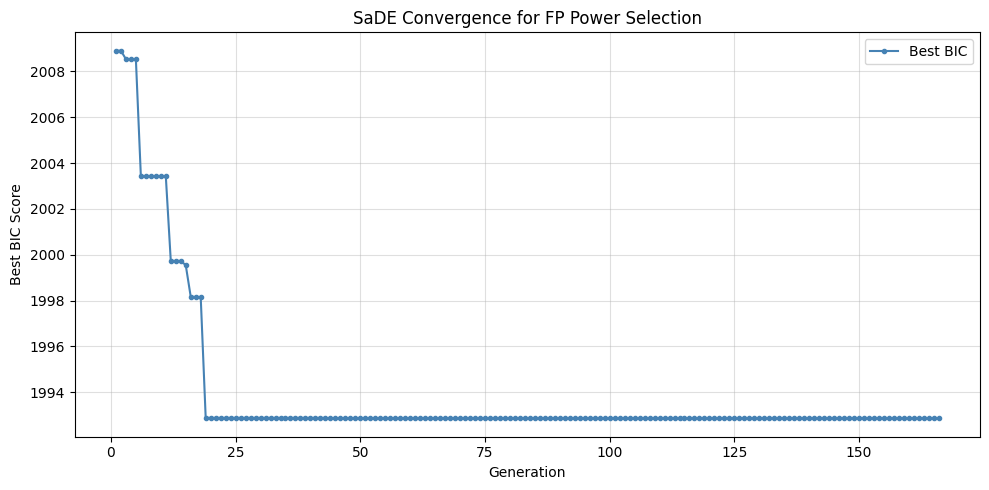


--- Final SaDE-FP Cox Model Summary ---


<lifelines.CoxPHFitter: fitted with 300 total observations, 91 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 300
number of events observed = 209
   partial log-likelihood = -993.76
         time fit was run = 2026-03-14 10:44:50 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
biomarker2_fp1_-1 18.27  8.61e+07     14.11           -9.39           45.93                0.00            8.85e+19

                   cmp to    z    p  -log2(p)
covariate                                    
biomarker2_fp1_-1    0.00 1.29 0.20      2.36
---
Concordance = 0.53
Partial AIC = 1989.52
log-likelihood ratio test = 1.61 on 1 df
-log2(p) of ll-ratio test = 2.29

In [10]:
if __name__ == "__main__":

    # == Synthetic dataset (same as original notebook) =========================
    np.random.seed(42)
    n  = 300
    df = pd.DataFrame({
        'age'       : np.random.uniform(30, 80, n),
        'biomarker1': np.random.exponential(1.5, n),
        'biomarker2': np.random.normal(50, 10, n),
        'duration'  : np.random.randint(1, 100, n),
        'event'     : np.random.binomial(1, 0.7, n),
    })

    continuous_features = ['age', 'biomarker1', 'biomarker2']

    # Ensure strictly positive values for power/log transforms
    df_positive = preprocess_positive(df, continuous_features)

    # == SaDE-based power selection ============================================
    best_powers, best_bic = select_fp_cox_sade(
        df           = df_positive,
        features     = continuous_features,
        duration_col = 'duration',
        event_col    = 'event',
        max_evals    = 5_000,    # increase for deeper search (e.g. 50_000)
        pop_size     = 30,
        seed         = 42,
    )

    # == Fit final Cox model with selected powers ===============================
    final_df = generate_fp_features(df_positive, continuous_features, best_powers)
    final_df['duration'] = df_positive['duration']
    final_df['event']    = df_positive['event']

    final_cph = CoxPHFitter(penalizer=0.01)
    final_cph.fit(final_df, duration_col='duration', event_col='event')
    print("\n--- Final SaDE-FP Cox Model Summary ---")
    final_cph.print_summary()

## 6. Comparison: Traditional Cox vs SaDE-FP Cox

In [11]:
# == Traditional Cox (linear covariates, no FP transformation) =============
print("Fitting Traditional Cox Model (Linear Covariates)")
trad_df  = df_positive[continuous_features + ['duration', 'event']].copy()
trad_cph = CoxPHFitter(penalizer=0.01)
trad_cph.fit(trad_df, duration_col='duration', event_col='event')
n_ev_t   = max(trad_df['event'].sum(), 2)
trad_bic = -2 * trad_cph.log_likelihood_ + len(trad_cph.params_) * np.log(n_ev_t)
print("\n--- Traditional Cox Model Summary ---")
trad_cph.print_summary()
# == Model comparison table ================================================
print("\n" + "="*65)
print("MODEL COMPARISON RESULTS")
print("="*65)
print(f"{'Metric':<22} | {'Traditional Cox':>18} | {'SaDE-FP Cox':>18}")
print("-"*65)
print(f"{'Log-Likelihood':<22} | {trad_cph.log_likelihood_:>18.4f} "
      f"| {final_cph.log_likelihood_:>18.4f}")
print(f"{'BIC (lower = better)':<22} | {trad_bic:>18.4f} "
      f"| {best_bic:>18.4f}")
print(f"{'Concordance Index':<22} | {trad_cph.concordance_index_:>18.4f} "
      f"| {final_cph.concordance_index_:>18.4f}")
print("-"*65)
if best_bic < trad_bic:
    print("\nConclusion: SaDE-FP Cox achieved a LOWER BIC — better fit!")
else:
    print("\nConclusion: Traditional Cox achieved a lower BIC.")
    print("Tip: increase max_evals (e.g. 50_000) for a deeper SaDE search.")

Fitting Traditional Cox Model (Linear Covariates)

--- Traditional Cox Model Summary ---


<lifelines.CoxPHFitter: fitted with 300 total observations, 91 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 300
number of events observed = 209
   partial log-likelihood = -993.70
         time fit was run = 2026-03-14 10:44:50 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
biomarker1 -0.02      0.98      0.04           -0.11            0.06                0.90                1.06
biomarker2 -0.01      0.99      0.01           -0.02            0.01                0.98                1.01

            cmp to     z    p  -log2(p)
covariate                              
age           0.00 -0.38 0.71      0.50
biomarker1    0.00 -0.50 0.62      0.69
biomarker2    0.00 -1.19 0.23      2.10
---
Concordance = 0.52
Partial AIC = 1993.40
log-likelihood ratio test = 1.73 on 3 df
-log2(p) of ll-ratio test = 0.67


MODEL COMPARISON RESULTS
Metric                 |    Traditional Cox |        SaDE-FP Cox
-----------------------------------------------------------------
Log-Likelihood         |          -993.7005 |          -993.7590
BIC (lower = better)   |          2003.4280 |          1992.8603
Concordance Index      |             0.5210 |             0.5303
-----------------------------------------------------------------

Conclusion: SaDE-FP Cox achieved a LOWER BIC — better fit!
